In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_DA_INA = df[(df['job_title_short'] ==  'Data Analyst') & (df['job_country'] == 'United States') ].copy()

df_DA_INA = df_DA_INA.dropna(subset=['salary_year_avg'])

df_DA_INA.salary_year_avg.sample(10)

763896     89952.0
180648     65000.0
600593    104000.0
22279      57500.0
7350      150000.0
323430     65000.0
700823     80000.0
736946     74801.5
449712    100000.0
566865     60000.0
Name: salary_year_avg, dtype: float64

<Axes: >

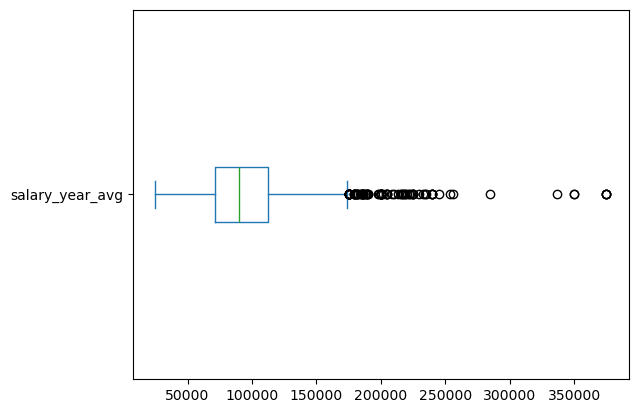

In [4]:
df_DA_INA['salary_year_avg'].plot(kind='box', vert= False)

C:\Users\Fathur Zhafran\AppData\Local\Temp\ipykernel_26500\742811455.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


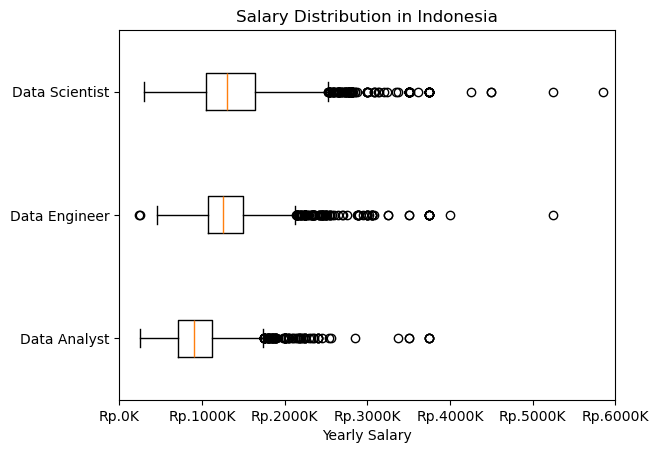

In [15]:
# box plot using matplotlib 
# plt.boxplot(job_list, labels=job_titles, vert=False)

# create job titles 
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# filter for job tilte in job titles above 
df_INA = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

# drop the nan value 
df_INA = df_INA.dropna(subset=['salary_year_avg'])

# create job list using for loop
job_list = [df_INA[df_INA['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in Indonesia')
plt.xlabel('Yearly Salary')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _ : f'Rp.{int(x/100)}K'))
plt.xlim(0,600000)
plt.show()